# Radical reading and political engagement: analysis notebook

This notebook contains the quantitative component of my capstone project on politically radical reading and political imagination, empathy, and action.

The dataset comes from an online survey of 169 participants, focused on how often and how deeply people engage with politically radical texts, and how this relates to their emotional and imaginative responses, empathy, and political action.

The code is structured to:
- Load and clean the raw survey data.
- Construct composite scales for radical reading engagement (RLI), empathy/perspective taking (EMP), imagination/speculative orientation (IMG), and action/engagement (ACT).
- Describe the sample and the scales.
- Evaluate reliability and item behaviour, including reverse-worded items.
- Explore associations between scales.
- Fit exploratory factor analysis and clustering models to identify underlying patterns.
- Use K-means clustering to build participant profiles
- Build OLS nested models and text with anova to fit exploratory models.



## Load, inspect  

In [54]:
import pandas as pd
# add in all my imports for cleaning
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
!pip install pingouin
import pingouin as pg
# for the clustering and visulaising
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
#for factor analysis
!pip install factor_analyzer
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo
#for OLS anova
from statsmodels.stats.anova import anova_lm

## Data loading

Here I mount Google Drive in Colab and load the cleaned survey export from Excel.

- The file Capstone Data Anonymised.xlsx contains one row per participant and one column per survey item.


The sample is self-selected via online recruitment; I treat it as exploratory rather than representative of any national population.

Also for anyone runnning this the data probably has a different name in the github repository so check that out.


In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
df = pd.read_excel('/content/drive/MyDrive/collar/Copy of Radical Reading(1-169).1.xlsx')

## Variable naming and initial cleaning

This block renames the raw survey columns to shorter, interpretable variable names.

- A items capture dimensions of radical reading engagement (depth, emotional response, social discussion, perception, fiction, form).
- B items capture empathy and perspective taking.
- C items capture imagination/speculative orientation.
- D items capture political action and engagement.

## Cleaning

In [57]:
rename_map = {
    "Id": "id",
    "How old are you?": "age_group",
    "What is your gender identity?": "gender",
    "How would you broadly describe your political outlook?\xa0": "political_outlook",
    "In the past 12 months, how many books, essays, or long-form texts would you describe as 'politically radical' have you read?": "A1_freq",
    "When did you last read a text you would describe as politically radical?": "A2_recency",
    "When reading politically radical literature, I actively think about how the ideas connect to the world around me.": "A3_depth",
    "I often feel emotionally moved or unsettled by ideas I encounter in politically radical texts.": "A4_emotional_response",
    "After reading politically radical literature, I often discuss the ideas with friends, family, or colleagues.": "A5_social",
    "The politically radical texts I have read have challenged assumptions I previously took for granted.": "A6_perception",
    "Fictional radical stories (novels, short stories, graphic novels) help me emotionally grasp political issues more than non‑fiction analysis.": "A7_fiction",
    "Poetry or experimental writing that deals with radical politics makes those ideas feel more immediate and personal to me.": "A8_form",
    "I often have tender, concerned feelings for people who are less fortunate than me.": "B1_EC_others",
    "When I hear about people being treated unfairly by social or political systems, I feel personally affected.": "B2_EC_injustice",
    "Stories about injustice or suffering rarely move me on a personal level.": "B3_unmoved_by_injustice_REVERSE",
    "I sometimes try to understand people whose lives are very different from mine by imagining how things look from their perspective.": "B4_PT_cognitive",
    "I find it difficult to imagine the daily lived experience of someone from a very different social or economic background than my own.": "B5_PT_class_REVERSE",
    "When I read a novel or story, I become deeply absorbed in the feelings of the characters.": "B6_EC_fictional",
    "When I hear political views I disagree with, I try to imagine the life experiences that might have led someone to hold those views.": "B7_PT_temporal",
    "I feel a strong sense of care and protectiveness toward people who are targeted by unfair laws or policies.": "B8_PT_legal",
    "I can clearly imagine concrete ways in which society could be organised differently from how it is today.": "C1_SI_alt_futures",
    "I often find myself questioning whether current social and political arrangements are inevitable or natural.": "C2_SC_question_status_quo",
    "I believe that collective human action can bring about meaningful improvements to the way society is organised.": "C3_collective_hope",
    "When thinking about political issues, I often think about what the world might look like decades from now, not just in the near future.": "C4_long_term",
    "Imagining radically different ways of organising society feels unrealistic to me.": "C5_diff_change_unrealistic_REVERSE",
    "When I engage with fiction or political writing, it expands my sense of what is possible in the world.": "C6_literary_inpso",
    "Even when I read radical literature, I struggle to picture how the ideas could translate into real future societies.": "C7_literary_innefectivenens_REVERSE",
    "In the past year, I have contacted or attempted to contact an elected official or public body about a political issue.": "D1_contacted_official_CONV",
    "I have attended a demonstration, protest march, or act of civil disobedience in the past year.\xa0": "D2_participation_NON",
    "I regularly share or discuss political ideas online (for example through social media, forums, or newsletters) with the aim of influencing others.\xa0": "D3_digital",
    "I intend to become more involved in efforts to bring about social or political change over the coming year.\xa0": "D4_action_intention",
    "I am more motivated to take part in political action when it benefits a wider community, even if it does not personally benefit me.\xa0": "D5_collective_over_individual",
    "Reading about characters or historical figures who take political risks makes me more willing to consider taking risks for what I believe in.": "D6_inspired_by_risk_taking_chars",
    "Practical radical books (for example, guides to organising or mutual aid) make me more likely to try new forms of political or community action.": "D7_practical_texts_prompt_action",
    "After engaging with radical literature, I pay more attention to opportunities in my everyday life to support social or political change.": "D8_notice_opportunities_to_act",
}

df = df.rename(columns=rename_map)
df.columns.tolist()

['ID',
 'age_group',
 'gender',
 'political_outlook',
 'A1_freq',
 'A2_recency',
 'A3_depth',
 'A4_emotional_response',
 'A5_social',
 'A6_perception',
 'A7_fiction',
 'A8_form',
 'B1_EC_others',
 'B2_EC_injustice',
 'B3_unmoved_by_injustice_REVERSE',
 'B4_PT_cognitive',
 'B5_PT_class_REVERSE',
 'B6_EC_fictional',
 'B7_PT_temporal',
 'B8_PT_legal',
 'C1_SI_alt_futures',
 'C2_SC_question_status_quo',
 'C3_collective_hope',
 'C4_long_term',
 'C5_diff_change_unrealistic_REVERSE',
 'C6_literary_inpso',
 'C7_literary_innefectivenens_REVERSE',
 'D1_contacted_official_CONV',
 'D2_participation_NON',
 'D3_digital',
 'D4_action_intention',
 'D5_collective_over_individual',
 'D6_inspired_by_risk_taking_chars',
 'D7_practical_texts_prompt_action',
 'D8_notice_opportunities_to_act']

### Likert response cleaning

Here I:
- Identify all Likert-scale items.
- Strip whitespace and normalise the text (lowercase, single spaces).
- Map seven-category Likert responses to numeric scores from 1 (strongly disagree) to 7 (strongly agree).
- Reverse-code the four reverse-worded items.


- After this step, all Likert items can be treated as numeric scales for reliability, correlations, and factor analysis.


Note - Reverse wording is theoretically useful but can introduce measurement error; the later reliability diagnostics show that one item (B3) behaves poorly and is dropped from the EMP scale.


In [58]:
likert_cols = [
    "A3_depth",
    "A4_emotional_response",
    "A5_social",
    "A6_perception",
    "A7_fiction",
    "A8_form",
    "B1_EC_others",
    "B2_EC_injustice",
    "B3_unmoved_by_injustice_REVERSE",
    "B4_PT_cognitive",
    "B5_PT_class_REVERSE",
    "B6_EC_fictional",
    "B7_PT_temporal",
    "B8_PT_legal",
    "C1_SI_alt_futures",
    "C2_SC_question_status_quo",
    "C3_collective_hope",
    "C4_long_term",
    "C5_diff_change_unrealistic_REVERSE",
    "C6_literary_inpso",
    "C7_literary_innefectivenens_REVERSE",
    "D1_contacted_official_CONV",
    "D2_participation_NON",
    "D3_digital",
    "D4_action_intention",
    "D5_collective_over_individual",
    "D6_inspired_by_risk_taking_chars",
    "D7_practical_texts_prompt_action",
    "D8_notice_opportunities_to_act",

]

for col in likert_cols:
    df[col] = df[col].astype(str).str.strip()

In [59]:
# standardise text cause some of the likert columns have different capitalisations (nearly defeated me)
for c in likert_cols:
    df[c] = (
        df[c]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
    )


#map from string to numeric
likert_map_7 = {
    "strongly disagree": 1,
    "disagree": 2,
    "somewhat disagree": 3,
    "neither agree nor disagree": 4,
    "somewhat agree": 5,
    "agree": 6,
    "strongly agree": 7
}

# apply mapping
for c in likert_cols:
    df[c] = df[c].map(likert_map_7)


# reverse code the reverse questions
df["B3_unmoved_by_injustice"] = 8 - df["B3_unmoved_by_injustice_REVERSE"]
df["B5_PT_class"] = 8 - df["B5_PT_class_REVERSE"]

df["C5_diff_change_unrealistic"] = 8 - df["C5_diff_change_unrealistic_REVERSE"]
df["C7_picturing_alternatives"] = 8 - df["C7_literary_innefectivenens_REVERSE"]


### Political outlook recoding

These cells recode participants free-text political outlook into ordered categories (Far-left → Far-right) and a numeric scale.


- political_outlook_scaled collapses write-in identities (e.g. anarchist) into approximate left/right positions for descriptive plots.
- political_outlook_scaled_num is a numeric version used in correlations and potential modelling.

note: this mapping is very much subjective // alternative codings could shift the interpretation of political gradients, so I treat results involving this variable as exploratory, ther are also very few of them thank goodness.


In [60]:
outlook_map = {
    # keep existing categories as they are
    'Far-left': 'Far-left',
    'Left': 'Left',
    'Centre-left': 'Centre-left',
    'Centre': 'Centre',
    'Centre-right': 'Centre-right',
    'Centre-right\xa0': 'Centre-right',
    'Right': 'Right',
    'Far-right': 'Far-right',

    # mapping others !! double check this
    'Anarchist': 'Far-left',
    "Far-left from an American perspective, but since this appears to be a UK-based survey you'd probably call it Left or Centre-left": 'Centre-left',
    'I am neither left or right. It depends on the topic of discussion.': 'Centre-right',
    'Left libertarian': 'Left',
    'Anarcho-communalist': 'Far-left',
    'Anti-civilisational Egoism': 'Far-left',
    'Modern Liberal, social democrat': 'Centre-right',
    'anarchist': 'Far-left'
}

In [61]:
#applying the mapping
df['political_outlook_scaled'] = df['political_outlook'].map(outlook_map)
df['political_outlook_scaled'] = df['political_outlook_scaled'].fillna('Other') #adding other back in or sometimes it gets confused when new data comes in

In [62]:
outlook_map_num = {
    # keep existing categories as they are
    'Far-left': 0,
    'Left': 1,
    'Centre-left': 2,
    'Centre': 3,
    'Centre-right': 4,
    'Centre-right\xa0': 4,
    'Right': 5,
    'Far-right': 6,

    # mapping others !! double check this
    'Anarchist': 0,
    "Far-left from an American perspective, but since this appears to be a UK-based survey you'd probably call it Left or Centre-left": 2,
    'I am neither left or right. It depends on the topic of discussion.': 4,
    'Left libertarian': 1,
    'Anarcho-communalist': 0,
    'Anti-civilisational Egoism': 0,
    'Modern Liberal, social democrat': 4,
    'anarchist': 0
}

In [63]:
#applying the mapping
df['political_outlook_scaled_num'] = df['political_outlook_scaled'].map(outlook_map_num)
df['political_outlook_scaled_num'] = pd.to_numeric(df['political_outlook_scaled_num'], errors='coerce')

### Reading frequency recoding

A1_freq reports how many politically radical texts respondents read in the past 12 months.

new mapping
I am treating frequency as an ordered scale which is reasonable for exploratory analysis, but differences between bands are not strictly equal. Aim to avoid look at this linearly


### Frequency mapping

In [64]:
freq_map = {
    "0": 0,
    "1-2": 1,
    "3-5": 2,
    "6-10": 3,
    "more than 10": 4,

}

df['A1_freq_num'] = df['A1_freq'].map(freq_map)
df['A1_freq_num'] = pd.to_numeric(df['A1_freq_num'], errors='coerce')

## Scale construction

This is where I define four main composite constructs:

- RLI (Radical reading engagement): depth, emotional response, social discussion, perception, fiction, form.
- EMP (Empathy / perspective taking): empathic concern and perspective taking across everyday and fictional contexts.
- IMG (Imaginative / speculative orientation): ability to imagine alternative futures and question the status quo.
- ACT (Action / engagement): digital and offline political action, intention, and noticing opportunities to act.


- These item lists are theory-based; reliability and factor analysis sections check how coherent they are empirically.
- I also keep a variant EMP scale that still includes the problematic B3 item (emp_items_wb3) to show its impact.


In [65]:
# RLI (radical reading engagement)
rli_items = [
    'A3_depth',
    'A4_emotional_response',
    'A5_social',
    'A6_perception',
    'A7_fiction',
    'A8_form'
]

# EMP (empathy / perspective taking)
emp_items = [
    'B1_EC_others',
    'B2_EC_injustice',
    'B4_PT_cognitive',
    'B5_PT_class',               # ''
    'B6_EC_fictional',
    'B7_PT_temporal',
    'B8_PT_legal'
]
# EMP (empathy / perspective taking)
emp_items_wb3 = [
    'B1_EC_others',
    'B2_EC_injustice',
    'B3_unmoved_by_injustice',   # reversed!
    'B4_PT_cognitive',
    'B5_PT_class',               # ''
    'B6_EC_fictional',
    'B7_PT_temporal',
    'B8_PT_legal'
]
# IMG (imaginative / speculative)
img_items = [
    'C1_SI_alt_futures',
    'C2_SC_question_status_quo',
    'C3_collective_hope',
    'C4_long_term',
    'C5_diff_change_unrealistic',  #''
    'C6_literary_inpso',
    'C7_picturing_alternatives'
]

# ACT (action / engagement)
act_items = [
    'D3_digital',
    'D4_action_intention',
    'D5_collective_over_individual',
    'D6_inspired_by_risk_taking_chars',
    'D7_practical_texts_prompt_action',
    'D8_notice_opportunities_to_act'
]

# Descriptive statistics and sample overview

This section describes:
- Who took part in the study (age, gender, political outlook).
- How participants scored on the four composite scales.
- How the scales relate to one another.

Interpretation:
- These descriptive plots provide the  grounding for later inferential and factor-analytic models.
- They also help check for obvious anomalies

### Participant characteristics

- These plots show the sample is skewed towards younger, left-leaning participants, which is consistent with the recruitment channels.
- Gender categories are diverse but may be unevenly distributed across clusters and scale scores.

 Because the sample is not representative of a general population, I treat these descriptives as context for the qualitative work and refrain from strong generalisation.


### Age Gender and Political Outlook

Text(0.5, 1.0, 'Political outlook distribution')

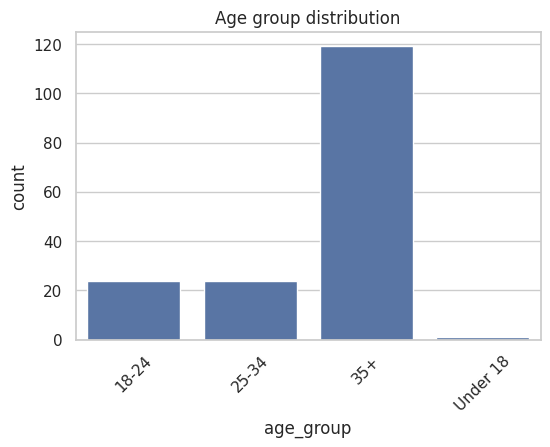

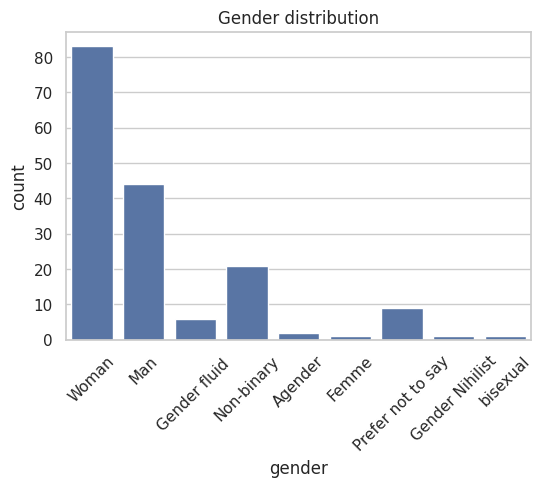

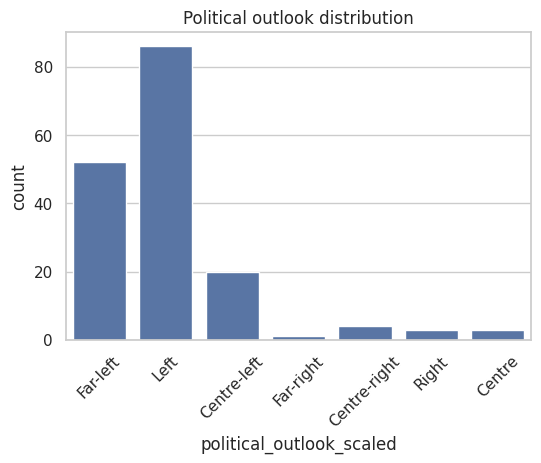

In [66]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='age_group', order=sorted(df['age_group'].dropna().unique()))
plt.xticks(rotation=45)
plt.title("Age group distribution")

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender')
plt.xticks(rotation=45)
plt.title("Gender distribution")

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='political_outlook_scaled')
plt.xticks(rotation=45)
plt.title("Political outlook distribution")



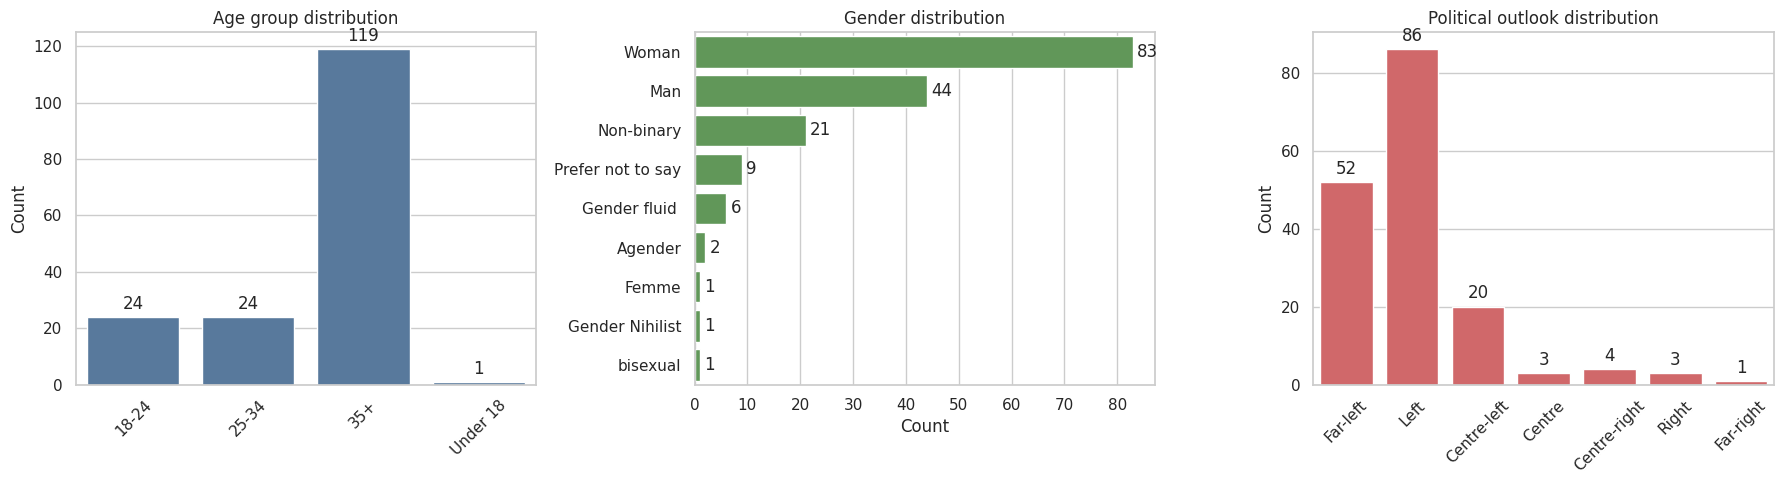

In [67]:

# Ugly but what can you do
sns.set(style="whitegrid", font_scale=1.0)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

age_order = sorted(df['age_group'].dropna().unique())
outlook_order = ['Far-left', 'Left', 'Centre-left', 'Centre', 'Centre-right', 'Right', 'Far-right', 'Other']

sns.countplot(data=df, x='age_group', order=age_order, color='#4C78A8', ax=ax[0])
ax[0].set_title('Age group distribution')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_xlabel('')
ax[0].set_ylabel('Count')

sns.countplot(data=df, y='gender', order=df['gender'].value_counts().index, color='#59A14F', ax=ax[1])
ax[1].set_title('Gender distribution')
ax[1].set_xlabel('Count')
ax[1].set_ylabel('')

sns.countplot(data=df, x='political_outlook_scaled',
              order=[o for o in outlook_order if o in df['political_outlook_scaled'].dropna().unique()],
              color='#E15759', ax=ax[2])
ax[2].set_title('Political outlook distribution')
ax[2].tick_params(axis='x', rotation=45)
ax[2].set_xlabel('')
ax[2].set_ylabel('Count')

for a in ax:
    for c in a.containers:
        a.bar_label(c, padding=3)

plt.tight_layout()
plt.show()

### Composite scale creation

Here I compute mean scores for each participant on the four composites:

- RLIscale, EMPscale, IMGscale, ACTscale.


- The .describe() output gives basic distributional properties (mean, SD, min, max, quartiles) for each scale.
- All four scales are negatively skewed (participants tend towards higher agreement), which matters when interpreting linear models.

 Using mean scores assumes roughly interval-like behaviour of the Likert items - this is a pragmatic choice common in survey research, and I check reliability to support.


In [68]:
df['RLIscale'] = df[rli_items].mean(axis=1)
df['EMPscale'] = df[emp_items].mean(axis=1)
df['IMGscale'] = df[img_items].mean(axis=1)
df['ACTscale'] = df[act_items].mean(axis=1)

df[['RLIscale','EMPscale','IMGscale','ACTscale']].describe()

,RLIscale,EMPscale,IMGscale,ACTscale
count,169.000000,169.000000,169.000000,169.000000
mean,5.187179,5.679910,5.670330,5.132150
std,0.951614,0.819763,0.953486,1.239623
min,1.666667,2.428571,1.714286,1.000000
25%,4.666667,5.285714,5.285714,4.333333
50%,5.333333,5.857143,5.857143,5.333333
75%,5.833333,6.285714,6.285714,6.000000
max,7.000000,7.000000,7.000000,7.000000


### Scale distributions

This boxplot plus jittered points visualises the distribution of RLI, EMP, IMG, and ACT scores.

Interpretation:
- EMP and IMG sit slightly higher on average than RLI and ACT, suggesting participants are strongly imaginative and empathetic, with somewhat lower levels of action.
- The spread of ACT is wider, consistent with more variability in political engagement.



/tmp/ipykernel_2216/1638412279.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




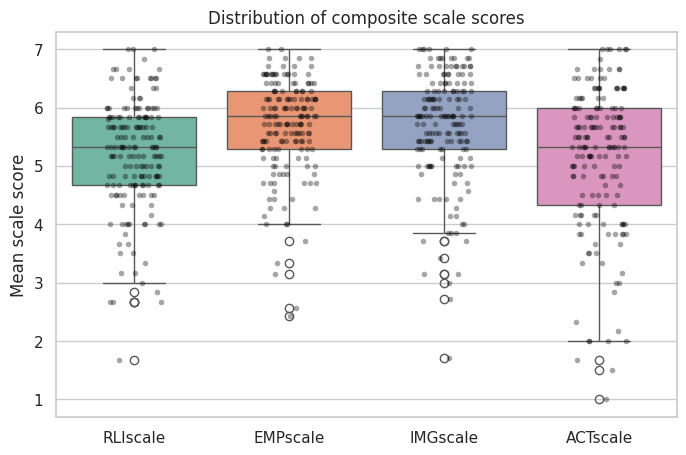

In [69]:
scale_cols = ['RLIscale', 'EMPscale', 'IMGscale', 'ACTscale']

df_long = df[scale_cols].melt(var_name='Scale', value_name='Score')

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_long, x='Scale', y='Score', palette='Set2')
sns.stripplot(data=df_long, x='Scale', y='Score', color='black', alpha=.35, jitter=.18, size=4)
plt.title('Distribution of composite scale scores')
plt.ylabel('Mean scale score')
plt.xlabel('')
plt.show()

### Relationships between scales

The next cells compute and plot the correlation matrix for the four composites.

Interpretation:
- The heatmap shows how strongly RLI, EMP, IMG, and ACT move together.
- In the actual output, RLI correlates most strongly with ACT, which is central to the research question about reading and action.


## Correlation matrixes

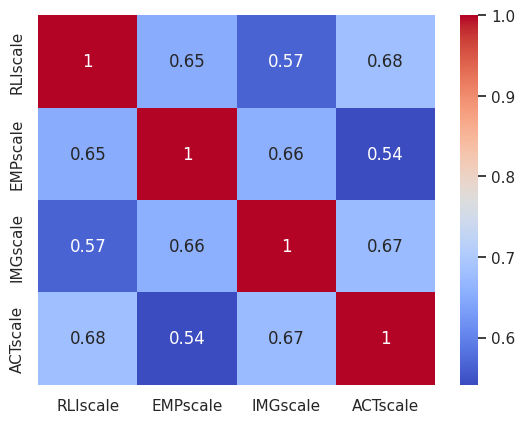

In [70]:
scale_cols = ["RLIscale", "EMPscale", "IMGscale", "ACTscale"]
corr = df[scale_cols].corr()
corr
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()
#find skipi or numpi matrix with the p values !!!!

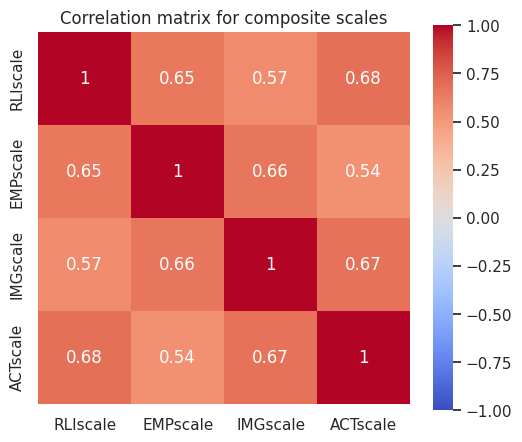

In [71]:
scale_cols = ['RLIscale', 'EMPscale', 'IMGscale', 'ACTscale']
corr = df[scale_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True)
plt.title('Correlation matrix for composite scales')
plt.show()

#added vmax and vmin

In [72]:
item_cols = rli_items + emp_items + img_items + act_items

In [73]:
item_corr = df[item_cols].corr()
# item_corr

### Item-level correlation structure

Here I compute and plot the full item-by-item correlation matrix across all RLI, EMP, IMG, and ACT items.

Interpretation:
- The heatmap lets me check whether items cluster roughly as expected
- Fiction/form items (A7, A8) and some reverse items stand out as less strongly integrated with their intended scales, which is consistent with their meaning.



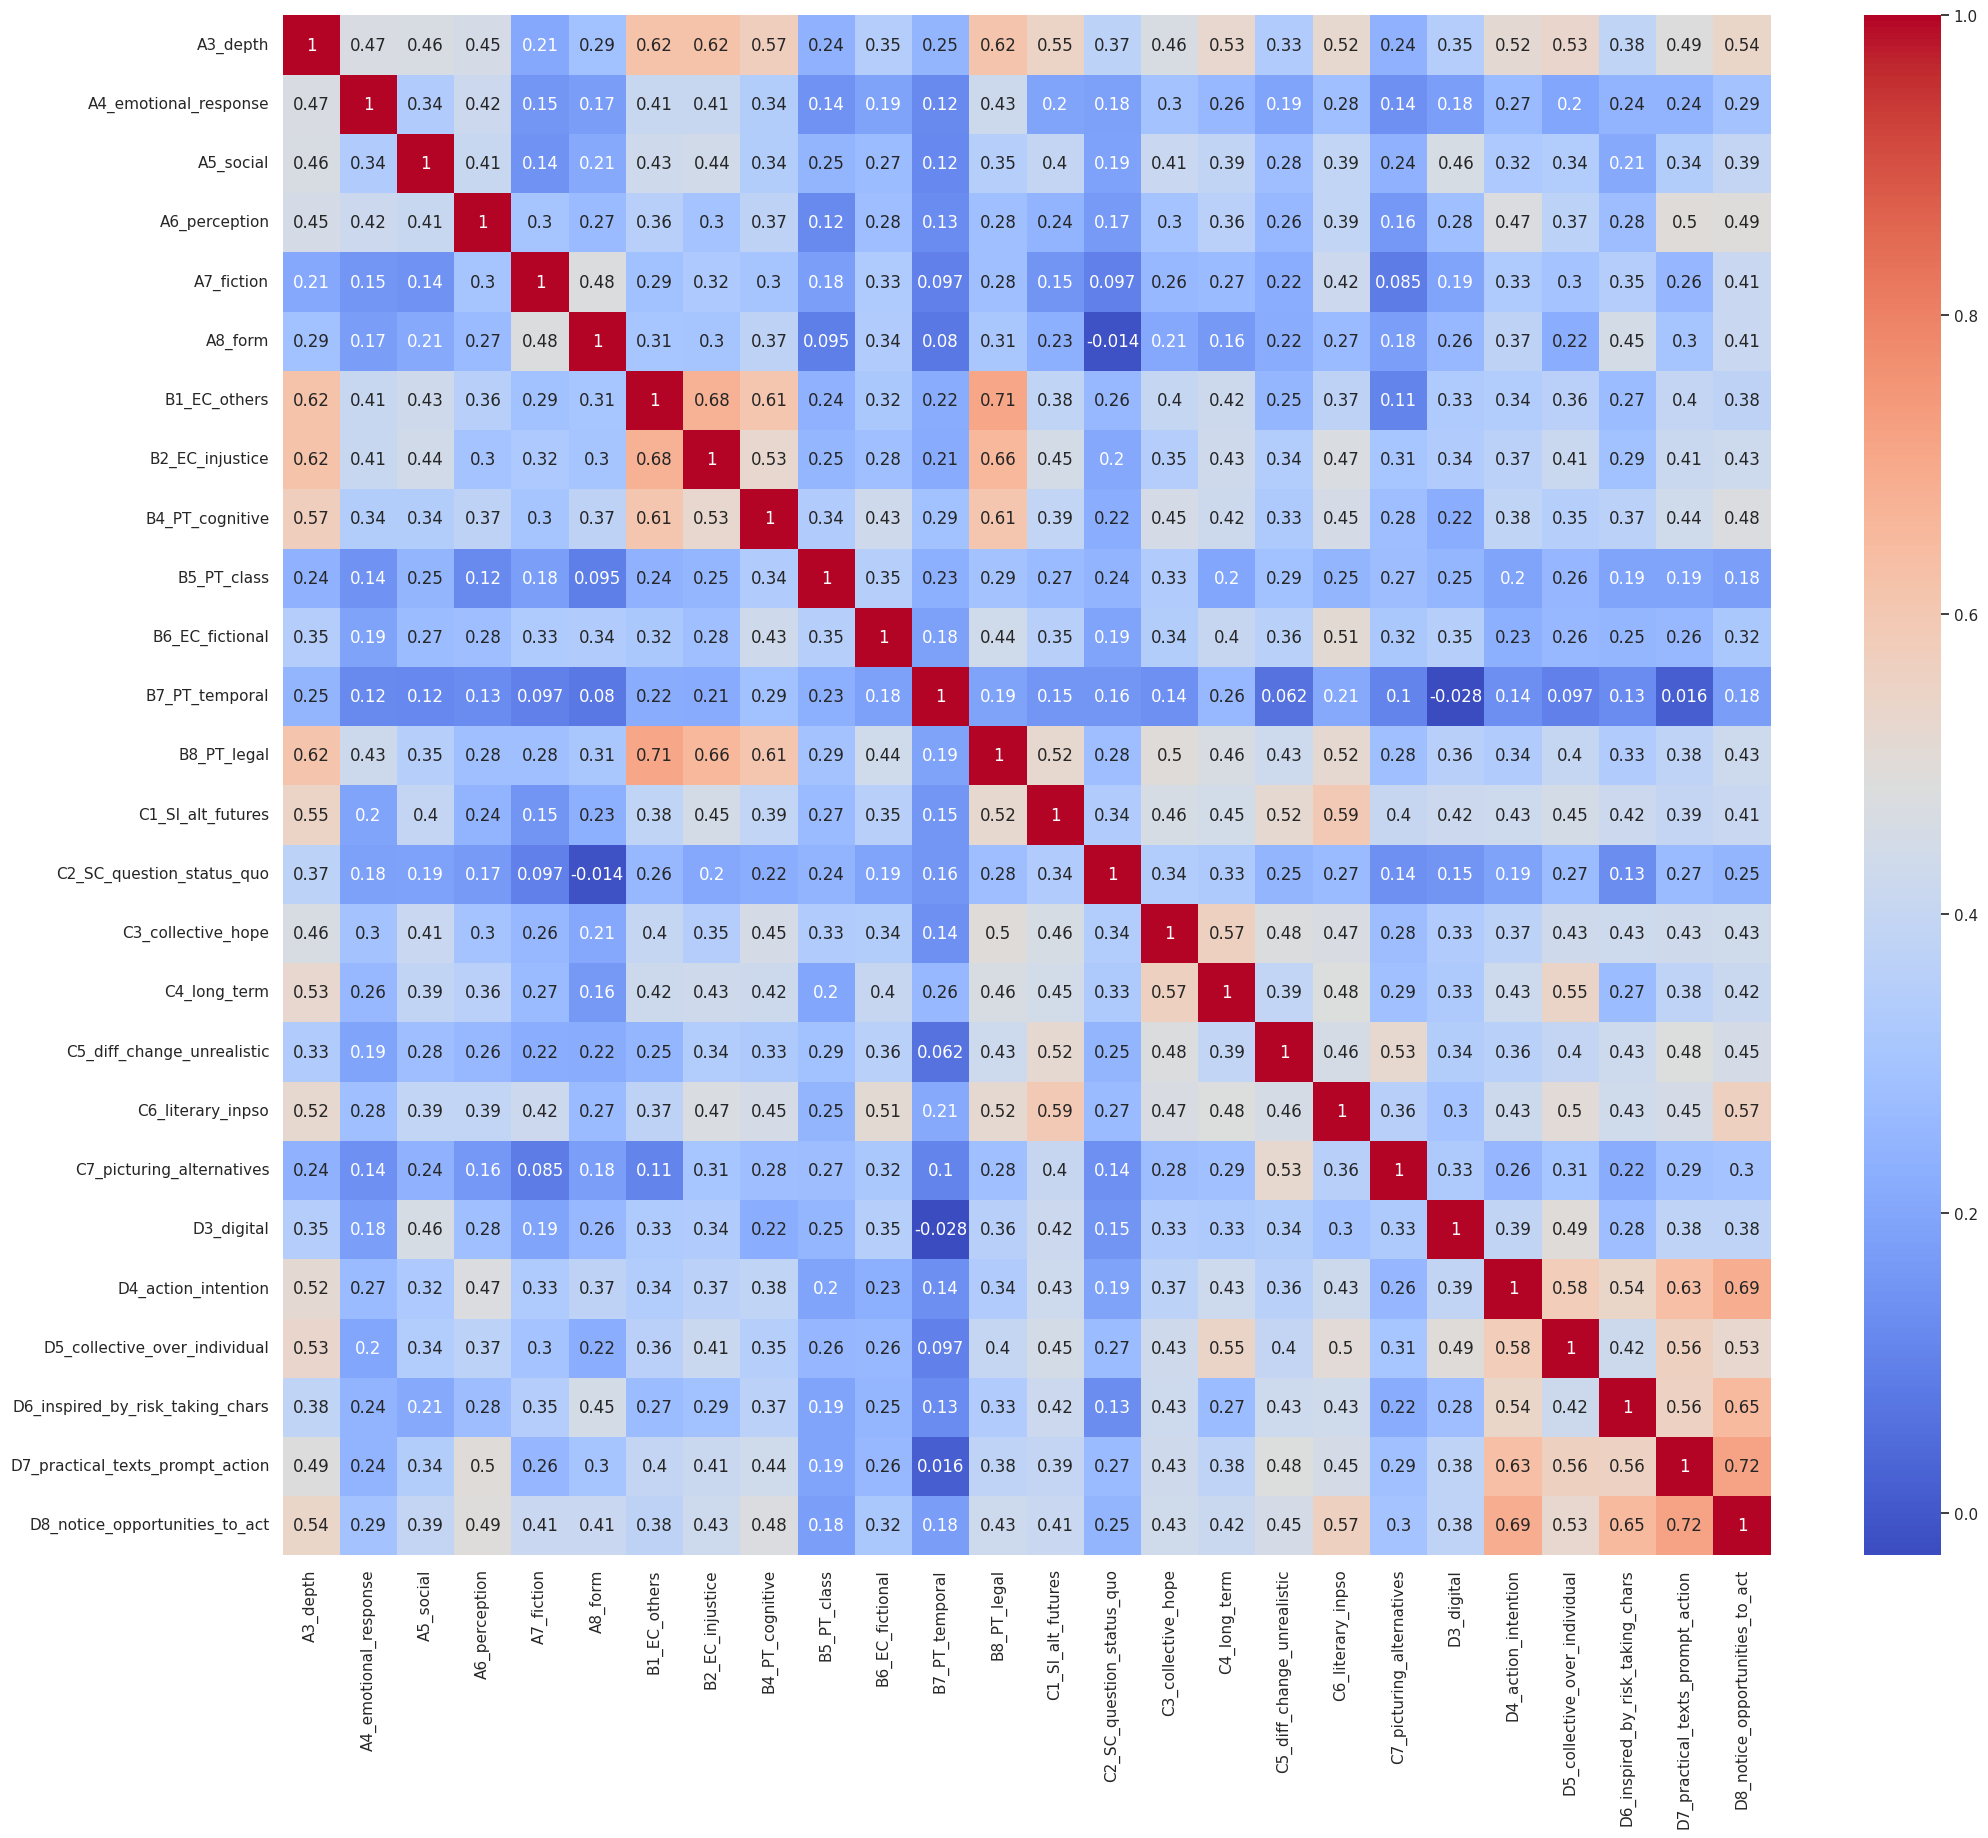

In [74]:
plt.figure(figsize=(24, 20))
sns.heatmap(item_corr, annot=True, cmap="coolwarm")
plt.show()

## Reliability and item behaviour


- Overlay histograms for raw vs reversed items show that reverse coding works mechanically but B3 remains an outlier.
- Cronbach’s alpha values and item-total plots


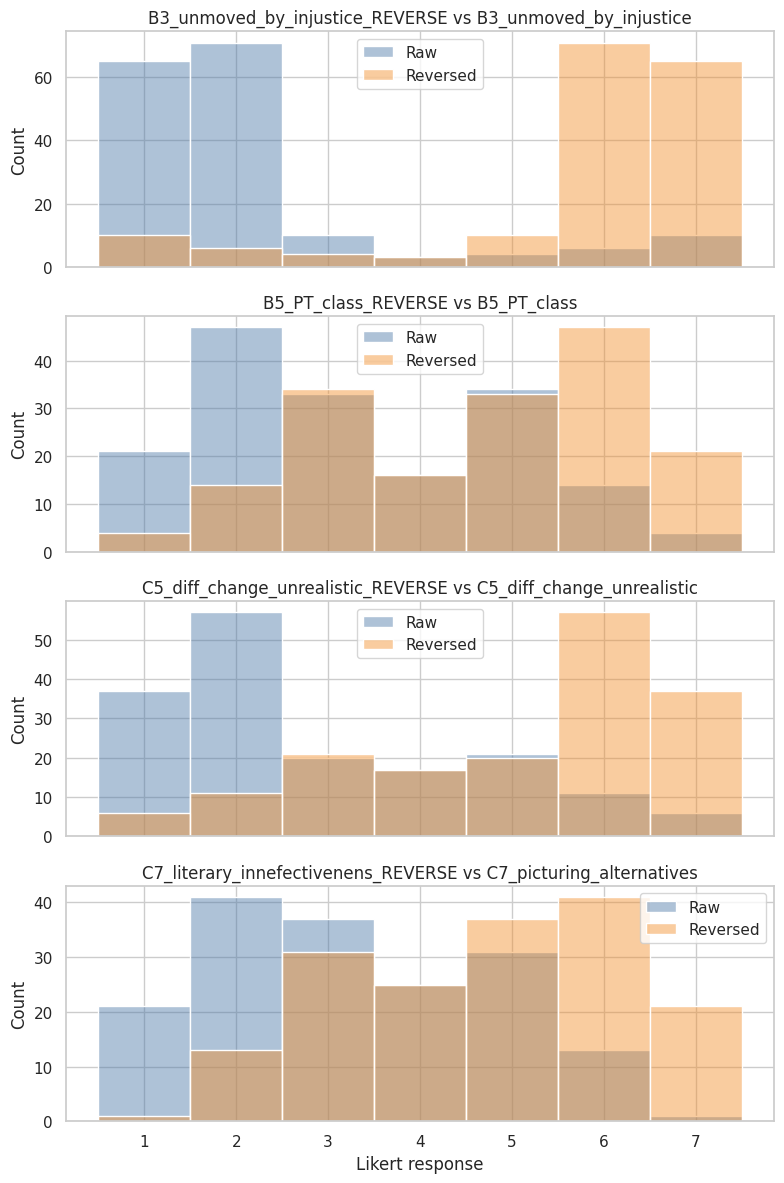

In [75]:
# this is the difference in distribution for normal and reverse format, even here you can visibly see b3 does remain an outlier
pairs = [('B3_unmoved_by_injustice_REVERSE','B3_unmoved_by_injustice'),
         ('B5_PT_class_REVERSE','B5_PT_class'),
         ('C5_diff_change_unrealistic_REVERSE','C5_diff_change_unrealistic'),
         ('C7_literary_innefectivenens_REVERSE','C7_picturing_alternatives')]

fig, ax = plt.subplots(len(pairs), 1, figsize=(8, 3 * len(pairs)), sharex=True)

for i, (raw, rev) in enumerate(pairs):
    sns.histplot(df[raw], discrete=True, stat='count', color='#4C78A8', alpha=.45, ax=ax[i], label='Raw')
    sns.histplot(df[rev], discrete=True, stat='count', color='#F28E2B', alpha=.45, ax=ax[i], label='Reversed')
    ax[i].set_title(f'{raw} vs {rev}')
    ax[i].set_xticks(range(1, 8))
    ax[i].legend()
    ax[i].set_xlabel('Likert response')
    ax[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Cronbach’s alpha for composite scales

The following code uses pingouin to compute Cronbach’s alpha and confidence intervals for:
- RLI
- EMP (without B3)
- EMPB3 (with B3)
- IMG
- ACT

Interpretation:
- All scales have acceptable reliability (alpha roughly 0.72–0.85).
- EMP is more reliable without B3 than with it, supporting the decision to exclude B3




In [76]:
for name, items in [
    ('RLI', rli_items),
    ('EMP', emp_items),
    ('EMPB3', emp_items_wb3),
    ('IMG', img_items),
    ('ACT', act_items)
]:
    alpha = pg.cronbach_alpha(df[items])
    print(name, alpha)

RLI (np.float64(0.7202001066409057), array([0.649, 0.781]))
EMP (np.float64(0.7906602245385439), array([0.739, 0.836]))
EMPB3 (np.float64(0.7510097274422967), array([0.69 , 0.804]))
IMG (np.float64(0.8115480019439237), array([0.765, 0.852]))
ACT (np.float64(0.8510287499904495), array([0.813, 0.883]))


## Participant profiles via clustering

This section uses k-means clustering on the four composite scales (RLI, EMP, IMG, ACT), after standardisation, to identify participant profiles.




## K-means Clustering with PCA




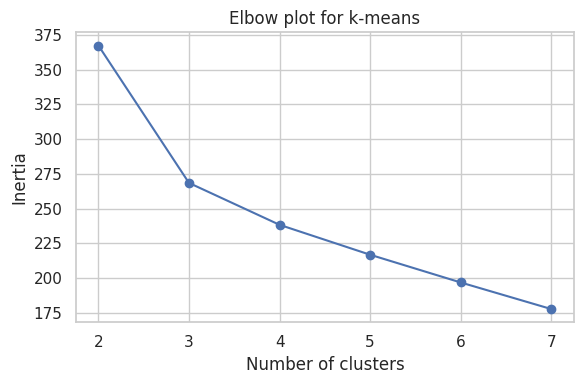

In [77]:

cluster_cols = ['RLIscale', 'EMPscale', 'IMGscale', 'ACTscale']

X = df[cluster_cols]


# standardising scales
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# first step elbow plot to see what is an appropriate n of clusters
inertias = []
ks = range(2, 8)
for n in ks:
    km = KMeans(n_clusters=n, random_state=42, n_init=20)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(ks), inertias, marker='o')
plt.title('Elbow plot for k-means')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()



From this I see that 3 clusters is the most obvious number to start with, but after exploring the data through the PCA visualisations I have decided that four cluters provide more insight into the data. The fouth cluster that appears is valuable for integration and the qualitative interpritations later.

In [78]:
# make the k based on the number of clusters ive chosen from visulaising the elbow
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_scaled)

#sticking the cluster labels back onto the data
X['cluster'] = labels

/tmp/ipykernel_2216/1969833811.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



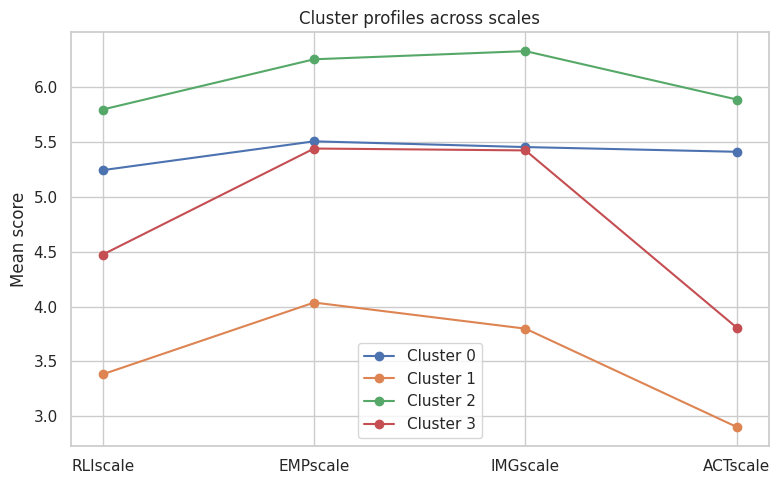

In [79]:
#Visualisin g the clusters in relationship to the mean scores of each of the subscales

profiles = X.groupby('cluster')[cluster_cols].mean().T

plt.figure(figsize=(8, 5))
for c in profiles.columns:
    plt.plot(profiles.index, profiles[c], marker='o', label=f'Cluster {c}')
plt.title('Cluster profiles across scales')
plt.ylabel('Mean score')
plt.xlabel('')
plt.legend()
plt.tight_layout()
plt.show()

Then I want to visulaise this using PCA so I can see it in two dimensions

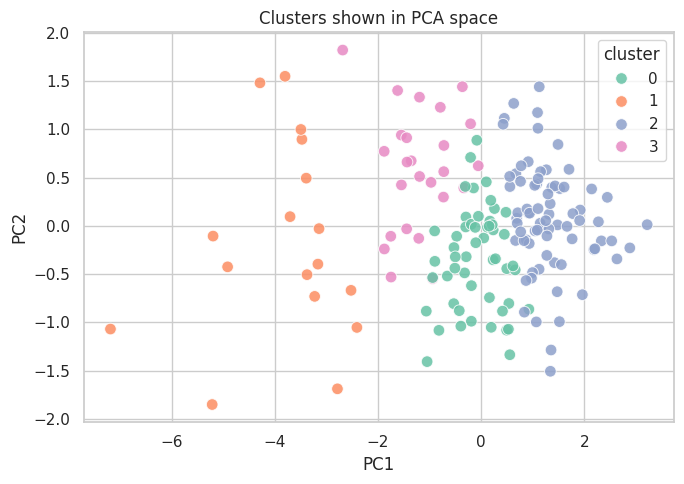

In [80]:


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=X.index)
pca_df['cluster'] = labels

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='cluster',
    palette='Set2', s=70, alpha=0.85
)
plt.title('Clusters shown in PCA space')
plt.tight_layout()
plt.show()

In [81]:
import plotly.express as px

# I can make this visulaisation interactive if I use plotly!
# This is super helpful for seeing how RLI follows the structure of the data as we progress up high in the other subscales in the data, but not 100% cleanly because afterall each of these dots are people

fig = px.scatter_3d(
    X,
    x='IMGscale',
    y='EMPscale',
    z='ACTscale',
    color='RLIscale',
    hover_data=['cluster'],
    title='IMG–EMP–ACT, coloured by RLI'
)

fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.update_layout(
    scene=dict(
        xaxis_title='IMGscale',
        yaxis_title='EMPscale',
        zaxis_title='ACTscale'
    )
)

fig.show()

In [82]:
# cluster sizes and percentages for my integration pathways (ADDED LATER)
cluster_counts = X['cluster'].value_counts().sort_index()
cluster_pct = (cluster_counts / cluster_counts.sum() * 100).round(1)

print("Cluster sizes and percentages:")
for c in cluster_counts.index:
    print(f"Cluster {c}: n={cluster_counts[c]}, {cluster_pct[c]}%")

Cluster sizes and percentages:
Cluster 0: n=52, 30.8%
Cluster 1: n=17, 10.1%
Cluster 2: n=75, 44.4%
Cluster 3: n=25, 14.8%


## Exploratory factor analysis (EFA)

This section asks whether the observed item patterns support the four conceptual scales (RLI, EMP, IMG, ACT), or whether a different latent structure fits better.


- Check EFA suitability via Bartlett’s test and KMO.
- Inspect a scree plot for the number of factors.
- Fit a 4-factor varimax-rotated solution.
- Visualise the loading matrix as a heatmap.

Interpretation:
- KMO is high and Bartlett’s test is highly significant, indicating strong shared variance suitable for EFA.
- Scree plot shows a dominant general factor plus smaller elbows around 4–5 factors.
- The 4-factor solution does not align perfectly with the original RLI/EMP/IMG/ACT grouping, but it yields interpretable clusters of items (e.g. action items loading together, fiction/form as a distinct factor).




## Factor Analysis (exploratory)

In [83]:
item_cols = rli_items + emp_items + img_items + act_items
X = df[item_cols].dropna()

In [84]:
# just checking that this data is suitible for EFA
chi2, p = calculate_bartlett_sphericity(X)
kmo_all, kmo_model = calculate_kmo(X)
print("Bartlett p:", p, "KMO:", kmo_model)

Bartlett p: 3.3819535774342723e-253 KMO: 0.9045633407098028


## scree plot
obvious elbow at 2, smaller at 4/5 which does somewhat validify using four / 5 factors

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



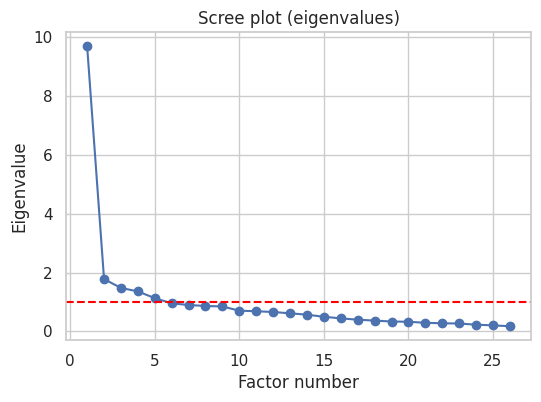

In [85]:
# too get the scree plot I do a test FA without rotation and just to see
fa_test = FactorAnalyzer(rotation=None)
fa_test.fit(X)

ev, v = fa_test.get_eigenvalues()

plt.figure(figsize=(6,4))
plt.plot(range(1, len(ev)+1), ev, marker="o")
plt.axhline(1, color="red", linestyle="--")
plt.xlabel("Factor number")
plt.ylabel("Eigenvalue")
plt.title("Scree plot (eigenvalues)")
plt.show()


In [86]:
ev

array([9.6911764 , 1.77674792, 1.47600464, 1.35694577, 1.1295142 ,
       0.95075609, 0.89583629, 0.86208739, 0.84599003, 0.7024328 ,
       0.6830554 , 0.65799438, 0.61238933, 0.56712704, 0.49548271,
       0.44158588, 0.39586184, 0.36547339, 0.33411838, 0.3258457 ,
       0.29091591, 0.27352937, 0.26660176, 0.22574076, 0.20371978,
       0.17306684])

In [87]:
#basic FA on four factors
fa4 = FactorAnalyzer(n_factors=4, rotation='varimax')
fa4.fit(X)
loadings = pd.DataFrame(fa4.loadings_, index=item_cols)
print(loadings)

                                         0         1         2         3
A3_depth                          0.639149  0.472962  0.226679  0.035846
A4_emotional_response             0.406153  0.234411  0.023209  0.079684
A5_social                         0.486532  0.306430  0.203914  0.022350
A6_perception                     0.374175  0.489578  0.013414  0.184902
A7_fiction                        0.166787  0.216242  0.083898  0.565710
A8_form                           0.120407  0.245861  0.077170  0.648782
B1_EC_others                      0.733116  0.205977  0.090265  0.204128
B2_EC_injustice                   0.586480  0.254850  0.276022  0.195251
B4_PT_cognitive                   0.511493  0.216836  0.267650  0.355262
B5_PT_class                       0.305622  0.011711  0.353963  0.122012
B6_EC_fictional                   0.348673  0.020836  0.404360  0.370806
B7_PT_temporal                    0.365515 -0.024199  0.057816  0.124046
B8_PT_legal                       0.628688  0.14432

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



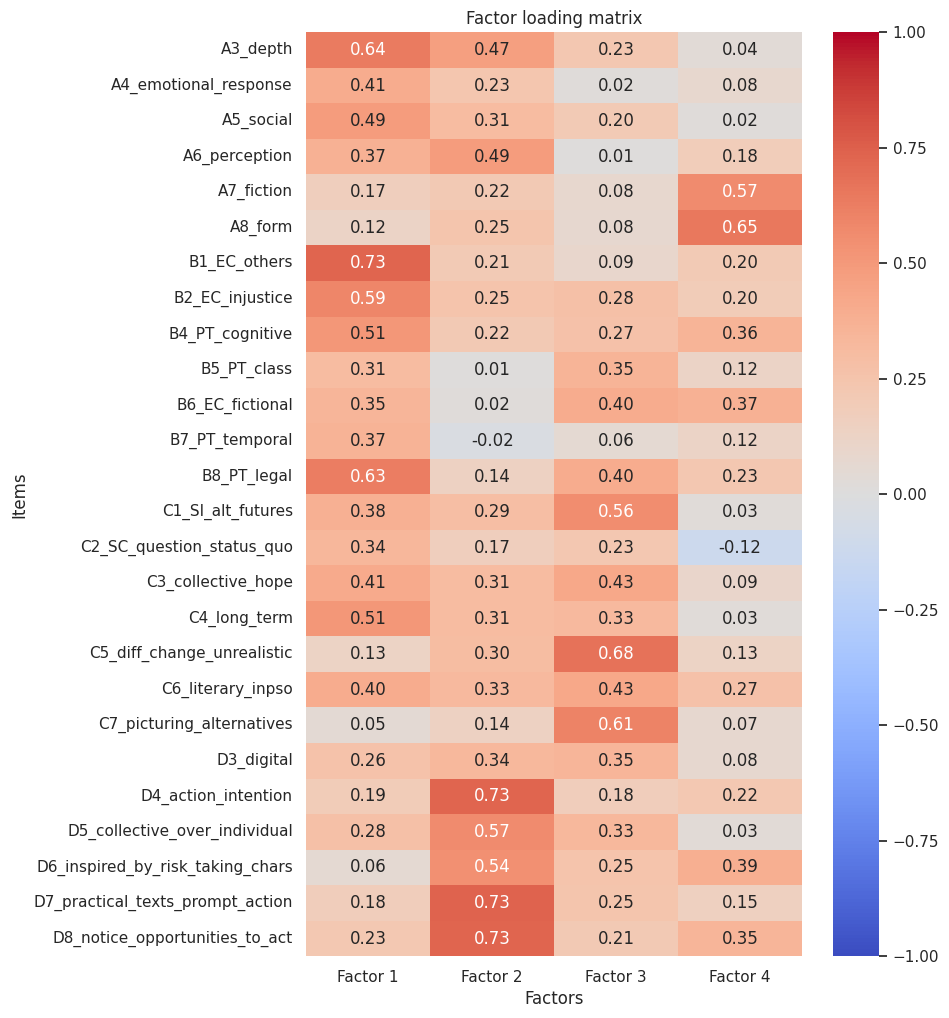

In [88]:
loadings = pd.DataFrame(
    fa4.loadings_,
    index=item_cols,
    columns=[f'Factor {i+1}' for i in range(fa4.n_factors)]
)

plt.figure(figsize=(8, 12))
sns.heatmap(loadings, cmap='coolwarm', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f')
plt.title('Factor loading matrix')
plt.xlabel('Factors')
plt.ylabel('Items')
plt.show()

# Associations between reading and outcomes

This final section focuses on inferential relationships:
- Regression and scatterplots showing how radical reading engagement (RLI) relates to action (ACT), empathy (EMP), and imagination (IMG).

Interpretation:
- RLI is a strong predictor of ACT in the simple models; visually, higher RLI corresponds to higher action scores.
- Associations with EMP and IMG are also positive, supporting the theoretical link between radical reading, empathy, and imagination.




# OLS regression

rli is a significant predictor! act is strongest with r2 46% explained! and rliscale coef is 0.87 roughly which would mean on my scale for each point up on rli someone is theyre like 0.87 points up on act! (holding nothing else constant cause its a bivariate model - should I look at constants??ASKNICCOLO)

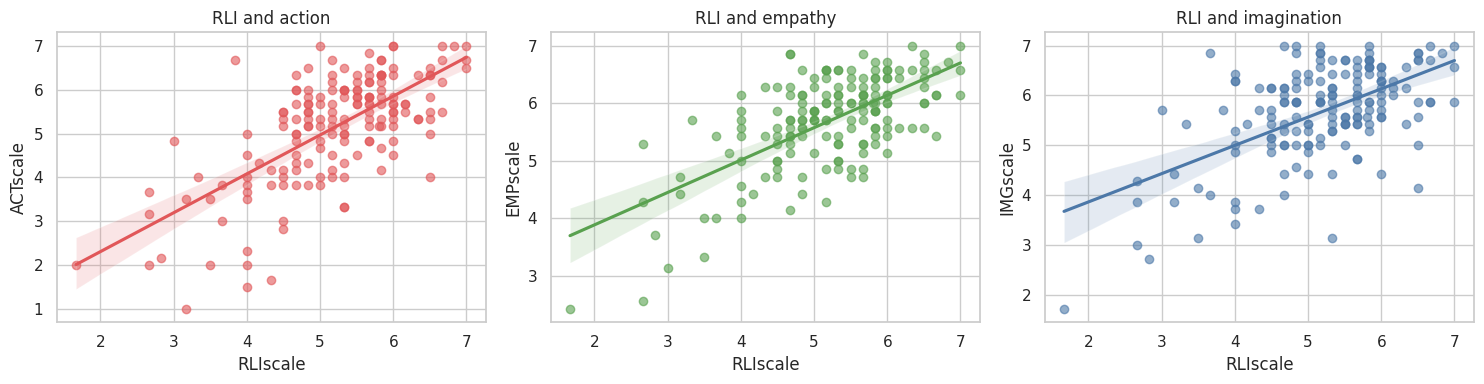

In [89]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.regplot(data=df, x='RLIscale', y='ACTscale', scatter_kws={'alpha':0.6}, ax=ax[0], color='#E15759')
ax[0].set_title('RLI and action')

sns.regplot(data=df, x='RLIscale', y='EMPscale', scatter_kws={'alpha':0.6}, ax=ax[1], color='#59A14F')
ax[1].set_title('RLI and empathy')

sns.regplot(data=df, x='RLIscale', y='IMGscale', scatter_kws={'alpha':0.6}, ax=ax[2], color='#4C78A8')
ax[2].set_title('RLI and imagination')

plt.tight_layout()
plt.show()

In [90]:
df_mod = df[['ACTscale','RLIscale','EMPscale','IMGscale',
                   'A1_freq','age_group','gender','political_outlook_scaled', 'political_outlook_scaled_num']].dropna()

In [91]:
# RLI predicts act?
m1 = smf.ols('ACTscale ~ RLIscale', data=df_mod).fit()
# RLI predicts emp?
m2 = smf.ols('EMPscale ~ RLIscale', data=df_mod).fit()
# RLI predicts img?
m3 = smf.ols('IMGscale ~ RLIscale', data=df_mod).fit()

In [92]:
print(m1.summary())
print(m2.summary())
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:               ACTscale   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     141.9
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           5.21e-24
Time:                        23:05:10   Log-Likelihood:                -217.09
No. Observations:                 167   AIC:                             438.2
Df Residuals:                     165   BIC:                             444.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6436      0.385      1.673      0.0


## emp as extra factor?


In [93]:
m4 = smf.ols('ACTscale ~ RLIscale + EMPscale', data=df_mod).fit()
print(m4.summary())
#not sure this is how to look for what im looking for, meither slope not r go up by much, thinkings

                            OLS Regression Results                            
Dep. Variable:               ACTscale   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     76.29
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           3.78e-24
Time:                        23:05:10   Log-Likelihood:                -214.00
No. Observations:                 167   AIC:                             434.0
Df Residuals:                     164   BIC:                             443.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1012      0.483     -0.210      0.8

In [94]:
# RLI predicts act depending on political outlook
m5 = smf.ols('ACTscale ~ A1_freq + political_outlook_scaled', data=df_mod).fit()
print(m5.summary())

                            OLS Regression Results                            
Dep. Variable:               ACTscale   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     12.04
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           2.81e-15
Time:                        23:05:10   Log-Likelihood:                -221.15
No. Observations:                 167   AIC:                             464.3
Df Residuals:                     156   BIC:                             498.6
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

# Nested OLS comparison models using ANOVA, AIC, BIC to compare

In [97]:
models = {
    "ACT ~ RLI": smf.ols("ACTscale ~ RLIscale", data=df).fit(),
    "ACT ~ RLI + EMP": smf.ols("ACTscale ~ RLIscale + EMPscale", data=df).fit(),
    "ACT ~ RLI + EMP + IMG": smf.ols("ACTscale ~ RLIscale + EMPscale + IMGscale", data=df).fit(),
    "ACT ~ RLI + EMP + IMG + outlook": smf.ols(
        "ACTscale ~ RLIscale + EMPscale + IMGscale + political_outlook_scaled_num",
        data=df
    ).fit(),
}

rows = []
for name, m in models.items():
    rows.append({
        "model": name,
        "AIC": m.aic,
        "BIC": m.bic,
        "R2": m.rsquared,
        "Adj_R2": m.rsquared_adj,
        "n_params": m.df_model + 1,
    })

comp_df = pd.DataFrame(rows).sort_values("AIC")
comp_df

,model,AIC,BIC,R2,Adj_R2,n_params
3,ACT ~ RLI + EMP + IMG + outlook,408.019445,423.668938,0.596029,0.586176,5.0
2,ACT ~ RLI + EMP + IMG,410.172530,422.692125,0.585979,0.578451,4.0
1,ACT ~ RLI + EMP,447.010405,456.400101,0.479012,0.472735,3.0
0,ACT ~ RLI,450.323075,456.582873,0.462374,0.459155,2.0


In [98]:
# defining my fiction/form items
ff_items = ["A7_fiction", "A8_form"]
df["FFscale"] = df[ff_items].mean(axis=1)

In [99]:
#seperating FF out of RLI
rli_core_items = ["A3_depth", "A4_emotional_response", "A5_social", "A6_perception"]
df["RLI_core"] = df[rli_core_items].mean(axis=1)

In [100]:
# do it again with the demographics to see unbivariate
models = {
    "ACT ~ age+gender+pol_outlook": smf.ols("ACTscale ~ age_group + gender + political_outlook_scaled_num", data=df).fit(),
    "+RLI_core": smf.ols("ACTscale ~ age_group + gender + political_outlook_scaled_num + RLI_core", data=df).fit(),
    "+FFscale": smf.ols("ACTscale ~ age_group + gender + political_outlook_scaled_num + RLI_core + FFscale", data=df).fit(),
    "+EMPscale": smf.ols("ACTscale ~ age_group + gender + political_outlook_scaled_num + RLI_core + FFscale + EMPscale", data=df).fit(),
    "+IMGscale": smf.ols("ACTscale ~ age_group + gender + political_outlook_scaled_num + RLI_core + FFscale + EMPscale + IMGscale", data=df).fit()

}

rows = []
for name, m in models.items():
    rows.append({
        "model": name,
        "AIC": m.aic,
        "BIC": m.bic,
        "R2": m.rsquared,
        "Adj_R2": m.rsquared_adj,
        "n_params": m.df_model + 1,   # includes intercept
    })

comp_df = pd.DataFrame(rows).sort_values("AIC")
comp_df

,model,AIC,BIC,R2,Adj_R2,n_params
4,+IMGscale,407.611798,460.617693,0.645044,0.607182,17.0
3,+EMPscale,426.776165,476.664066,0.597085,0.557060,16.0
2,+FFscale,428.146093,474.916000,0.588872,0.551005,15.0
1,+RLI_core,454.197799,497.933295,0.518304,0.477641,14.0
0,ACT ~ age+gender+pol_outlook,493.748279,534.359811,0.383143,0.335386,13.0


In [101]:
#now using anova to judge the different models

m1 = smf.ols("ACTscale ~ age_group + gender + political_outlook_scaled_num", data=df).fit()
m2 = smf.ols("ACTscale ~ age_group + gender + political_outlook_scaled_num + RLI_core", data=df).fit()
m3 = smf.ols("ACTscale ~ age_group + gender + political_outlook_scaled_num + RLI_core + FFscale", data=df).fit()
m4 = smf.ols("ACTscale ~ age_group + gender + political_outlook_scaled_num + RLI_core + FFscale + EMPscale + IMGscale", data=df).fit()

anova = anova_lm(m1, m2, m3, m4)
anova

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,155.0,159.222542,0.0,NaN,NaN,NaN
1,154.0,124.334881,1.0,34.887662,57.137199,3.401722e-12
2,152.0,106.083348,2.0,18.251533,14.945706,1.186823e-06
3,150.0,91.589180,2.0,14.494168,11.868898,1.639727e-05
